---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">GenAI & Advanced Nets: Classificação de Sentimentos com FCNN</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
</div>

---

In [1]:
# Obs: se você não estiver utilizando um ambiente virtual, instale as bibliotecas conforme se apresenta abaixo
# %pip install -q -r requirements.txt

# pip é o gerenciador de pacotes do Python. Pense nele como o instalador oficial de libs Python.
# no notebook, usar %pip ... é ideal porque instala no mesmo ambiente do kernel em uso.

# -q: quiet
# -r: requirement file, indica ao pip para instalar os pacotes listados no arquivo requirements.txt

---

<div align="center">

## <span style="color:#1E90FF;">Modelo FCNN</span>

</div>

Neste notebook utilizamos uma rede **FCNN** (*Fully Connected Neural Network*) sobre vetores **TF-IDF** para classificar sentimentos em **6 classes**: *anger*, *fear*, *joy*, *love*, *sadness* e *surprise*.

O **TF-IDF** (*Term Frequency–Inverse Document Frequency*) é uma técnica de vetorização de texto que pondera cada termo pela sua frequência no documento e pela raridade no corpus, produzindo representações esparsas e eficazes para tarefas de classificação textual. Esses vetores são então passados como entrada para uma rede totalmente conectada, composta por camadas densas com funções de ativação e regularização por *dropout*.

A arquitetura completa será apresentada em detalhe na etapa de treinamento, incluindo `model.summary()`.

In [2]:
# imports
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# fixando a seed para garantir reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


---

<div align="center">

## <span style="color:#1E90FF;">Tratamento de Dados</span>

</div>

Nesta etapa realizamos o pré-processamento dos dados textuais. As principais operações são:

- **Carga dos dados**: leitura dos arquivos de treino e teste;
- **Análise exploratória**: visualização da distribuição das classes para identificar possíveis desbalanceamentos;
- **Pré-processamento com spaCy**: lematização e remoção de stopwords e pontuação;
- **Separação treino/validação**: divisão estratificada para preservar a proporção entre as classes;
- **Codificação dos rótulos**: transformação dos rótulos textuais em identificadores numéricos.

In [3]:
def load_dataset(path: str) -> pd.DataFrame:
    """
    Lê o dataset separado por ';' dividindo sempre pelo ÚLTIMO ponto e vírgula,
    garantindo que textos que contenham ';' sejam lidos corretamente.
    Formato esperado por linha:  texto;sentimento
    """
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            idx = line.rfind(';')
            records.append({'texto': line[:idx], 'sentimento': line[idx + 1:]})
    return pd.DataFrame(records)

train_path = 'dataset/data_train.txt'
test_path  = 'dataset/data_test.txt'

df_train = load_dataset(train_path)
df_test  = load_dataset(test_path)

print('Shape treino:', df_train.shape)
print('Shape teste :', df_test.shape)
print('\nClasses no treino:', sorted(df_train['sentimento'].unique()))
print('Classes no teste :', sorted(df_test['sentimento'].unique()))

display(df_train.head(3))

Shape treino: (16000, 2)
Shape teste : (2000, 2)

Classes no treino: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Classes no teste : ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


,texto,sentimento
0,i am feeling completely overwhelmed i have two...,fear
1,i have the feeling she was amused and delighted,joy
2,i was able to help chai lifeline with your sup...,joy


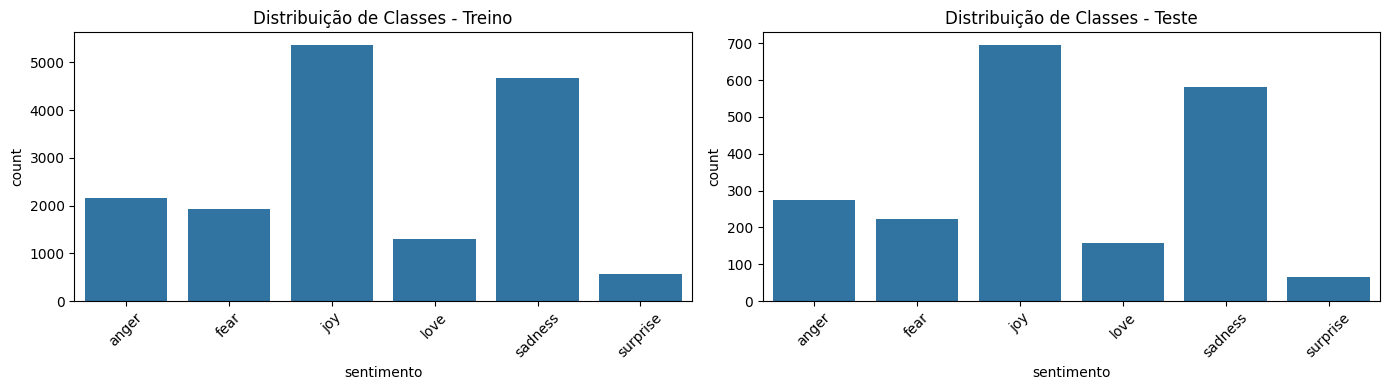

In [4]:
# distribuição das classes nos conjuntos de treino e teste
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df_train, x='sentimento', order=sorted(df_train['sentimento'].unique()), ax=axes[0])
axes[0].set_title('Distribuição de Classes - Treino')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df_test, x='sentimento', order=sorted(df_test['sentimento'].unique()), ax=axes[1])
axes[1].set_title('Distribuição de Classes - Teste')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [5]:
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
    nlp = spacy.load('en_core_web_sm')


def spacy_preprocess_text(texto: str) -> str:
    doc = nlp(str(texto))
    tokens = [
        tok.lemma_.lower().strip()
        for tok in doc
        if (not tok.is_stop) and (not tok.is_punct) and (not tok.is_space)
    ]
    return ' '.join([t for t in tokens if t])


df_train_spa = df_train.copy()
df_test_spa = df_test.copy()

df_train_spa['texto_processado'] = df_train_spa['texto'].apply(spacy_preprocess_text)
df_test_spa['texto_processado'] = df_test_spa['texto'].apply(spacy_preprocess_text)

display(df_train_spa[['texto', 'texto_processado', 'sentimento']].head(3))

,texto,texto_processado,sentimento
0,i am feeling completely overwhelmed i have two...,feel completely overwhelmed strategy help feel...,fear
1,i have the feeling she was amused and delighted,feeling amuse delight,joy
2,i was able to help chai lifeline with your sup...,able help chai lifeline support encouragement ...,joy


In [6]:
df_train_spa_inner, df_valid_spa = train_test_split(
    df_train_spa,
    test_size=0.2,
    random_state=SEED,
    stratify=df_train_spa['sentimento'],
)

le_global = LabelEncoder()
le_global.fit(df_train_spa['sentimento'])

X_train_txt = df_train_spa_inner['texto_processado'].tolist()
X_valid_txt = df_valid_spa['texto_processado'].tolist()
X_test_txt = df_test_spa['texto_processado'].tolist()

y_train_id = le_global.transform(df_train_spa_inner['sentimento'])
y_valid_id = le_global.transform(df_valid_spa['sentimento'])
y_test_id = le_global.transform(df_test_spa['sentimento'])

class_names = list(le_global.classes_)
num_classes = len(class_names)

classes_ids = np.unique(y_train_id)
weights = compute_class_weight(class_weight='balanced', classes=classes_ids, y=y_train_id)
class_weights_common = {int(c): float(w) for c, w in zip(classes_ids, weights)}

print('Classes:', class_names)
print('Treino:', len(X_train_txt), '| Validacao:', len(X_valid_txt), '| Teste:', len(X_test_txt))

Classes: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Treino: 12800 | Validacao: 3200 | Teste: 2000


---

<div align="center">

## <span style="color:#1E90FF;">Treinamento do Modelo</span>

</div>

Esta etapa cobre três fases encadeadas:

**1. Vetorização TF-IDF** — os textos pré-processados são transformados em vetores numéricos esparsos pelo `TfidfVectorizer`. Cada dimensão corresponde a um termo (ou bigrama), e seu valor reflete a importância do termo no documento em relação ao corpus. Apenas o conjunto de treino é usado para ajustar o vetorizador (`fit_transform`); os demais conjuntos apenas transformam (`transform`).

**2. Definição da arquitetura** — a rede FCNN é composta pelas seguintes camadas:

| Camada | Descrição |
|--------|-----------|
| `Dense(256, selu)` | Primeira camada densa com ativação SELU, que combina normalização e não-linearidade |
| `Dropout(0.3)` | Desliga 30% dos neurônios aleatoriamente durante o treino para reduzir overfitting |
| `Dense(128, selu)` | Segunda camada de compressão de representação |
| `Dropout(0.2)` | Regularização adicional |
| `Dense(64, selu)` | Camada intermediária de representação mais compacta |
| `Dense(softmax)` | Camada de saída com probabilidades para cada uma das `num_classes` classes |

**3. Treinamento** — utiliza o otimizador **Adam** com `sparse_categorical_crossentropy` como função de perda. O callback `EarlyStopping` monitora a `val_loss` e interrompe o treino caso não haja melhora por `patience=4` épocas consecutivas, restaurando automaticamente os pesos da melhor época.

In [7]:
# ── Preparação dos vetores ────────────────────────────────────────────────────

# hiperparâmetros do modelo
EPOCHS = 12
BATCH = 64

# TF-IDF: ajusta no treino e transforma os três conjuntos
# ngram_range=(1,2): considera unigramas e bigramas
# max_features=30000: limita o vocabulário às 30.000 features mais frequentes
# min_df=2: ignora termos que aparecem em menos de 2 documentos
tfidf_fcnn = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)
X_train_fcnn = tfidf_fcnn.fit_transform(X_train_txt).astype(np.float32).toarray()
X_valid_fcnn = tfidf_fcnn.transform(X_valid_txt).astype(np.float32).toarray()
X_test_fcnn = tfidf_fcnn.transform(X_test_txt).astype(np.float32).toarray()

print(f'Dimensão dos vetores TF-IDF: {X_train_fcnn.shape[1]} features')
print(f'Shape treino  : {X_train_fcnn.shape}')
print(f'Shape validação: {X_valid_fcnn.shape}')
print(f'Shape teste   : {X_test_fcnn.shape}')

# ── Arquitetura ───────────────────────────────────────────────────────────────

model_fcnn = Sequential([
    Dense(256, activation='selu', input_shape=(X_train_fcnn.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='selu'),
    Dropout(0.2),
    Dense(64, activation='selu'),
    Dense(num_classes, activation='softmax'),
])

model_fcnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

print('\nResumo da arquitetura FCNN:')
model_fcnn.summary()

# ── Treinamento ───────────────────────────────────────────────────────────────

# EarlyStopping: interrompe o treino quando val_loss não melhora por patience épocas
early_fcnn = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history_fcnn = model_fcnn.fit(
    X_train_fcnn,
    y_train_id,
    validation_data=(X_valid_fcnn, y_valid_id),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weights_common,
    callbacks=[early_fcnn],
    verbose=1,
)

Dimensão dos vetores TF-IDF: 11504 features
Shape treino  : (12800, 11504)
Shape validação: (3200, 11504)
Shape teste   : (2000, 11504)

Resumo da arquitetura FCNN:


/Users/mitoura/Desktop/FIAP/Materiais/GenerativeAI/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,945,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,986,822 (11.39 MB)

 Trainable params: 2,986,822 (11.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7515 - loss: 0.7872 - val_accuracy: 0.8591 - val_loss: 0.4323
Epoch 2/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9591 - loss: 0.1191 - val_accuracy: 0.8616 - val_loss: 0.4282
Epoch 3/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9875 - loss: 0.0462 - val_accuracy: 0.8581 - val_loss: 0.4951
Epoch 4/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9915 - loss: 0.0342 - val_accuracy: 0.8494 - val_loss: 0.5308
Epoch 5/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9940 - loss: 0.0251 - val_accuracy: 0.8534 - val_loss: 0.5714
Epoch 6/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9945 - loss: 0.0214 - val_accuracy: 0.8475 - val_loss: 0.5934


---

<div align="center">

## <span style="color:#1E90FF;">Avaliação do Modelo</span>

</div>

Com o modelo treinado, avaliamos seu desempenho no conjunto de teste, que não foi visto durante o treinamento. As métricas utilizadas são:

- **Loss e Acurácia**: métricas globais calculadas diretamente pelo Keras no conjunto de teste;
- **Acurácia geral**: proporção de amostras classificadas corretamente;
- **F1-Score Macro**: média do F1 por classe, sem ponderação — penaliza mais o desempenho ruim em classes menores;
- **F1-Score Weighted**: média do F1 ponderada pelo suporte de cada classe;
- **Relatório de classificação**: precisão, recall e F1 detalhados por classe;
- **Curvas de aprendizado**: evolução do *loss* e da acurácia ao longo das épocas de treino e validação;
- **Matriz de confusão**: visualização dos erros de predição entre classes.

=== Resultado: FCNN ===
Test loss         : 0.4199
Test accuracy     : 0.8690
Accuracy geral    : 0.8690
F1 Macro          : 0.8258
F1 Weighted       : 0.8697

              precision    recall  f1-score   support

       anger       0.84      0.83      0.83       275
        fear       0.85      0.81      0.83       224
         joy       0.92      0.90      0.91       695
        love       0.72      0.76      0.74       159
     sadness       0.91      0.91      0.91       581
    surprise       0.68      0.82      0.74        66

    accuracy                           0.87      2000
   macro avg       0.82      0.84      0.83      2000
weighted avg       0.87      0.87      0.87      2000



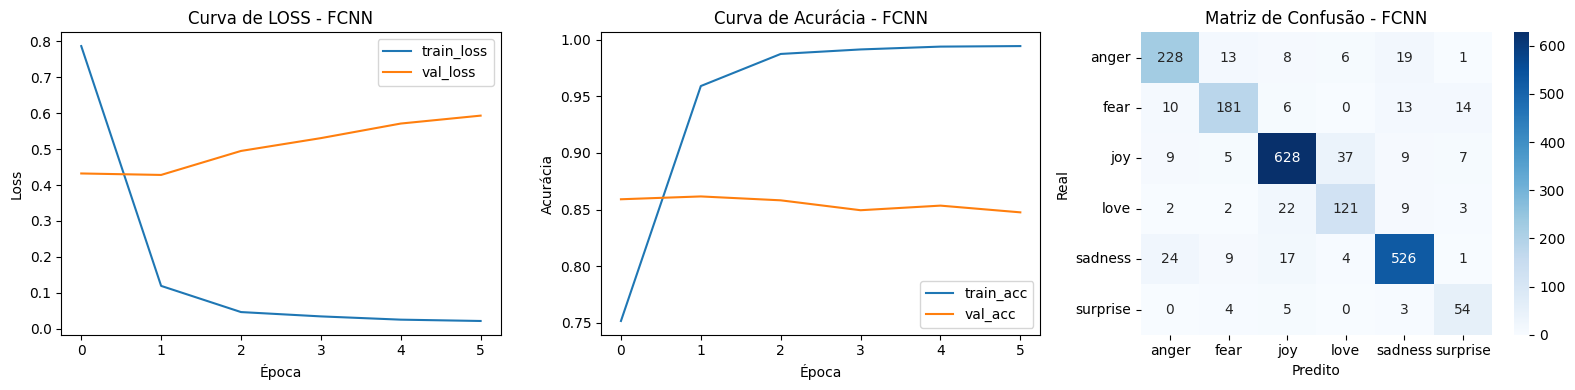

In [8]:
# avaliação do modelo no conjunto de teste
test_loss_fcnn, test_acc_fcnn = model_fcnn.evaluate(X_test_fcnn, y_test_id, verbose=0)
pred_fcnn = np.argmax(model_fcnn.predict(X_test_fcnn, verbose=0), axis=1)

y_true_lbl = le_global.inverse_transform(y_test_id)
y_pred_fcnn_lbl = le_global.inverse_transform(pred_fcnn)

fcnn_acc = accuracy_score(y_true_lbl, y_pred_fcnn_lbl)
fcnn_f1_macro = f1_score(y_true_lbl, y_pred_fcnn_lbl, average='macro')
fcnn_f1_weighted = f1_score(y_true_lbl, y_pred_fcnn_lbl, average='weighted')

# métricas gerais
print('=== Resultado: FCNN ===')
print(f'Test loss         : {test_loss_fcnn:.4f}')
print(f'Test accuracy     : {test_acc_fcnn:.4f}')
print(f'Accuracy geral    : {fcnn_acc:.4f}')
print(f'F1 Macro          : {fcnn_f1_macro:.4f}')
print(f'F1 Weighted       : {fcnn_f1_weighted:.4f}\n')
print(classification_report(y_true_lbl, y_pred_fcnn_lbl, zero_division=0))

# curvas de aprendizado
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
plt.plot(history_fcnn.history['loss'], label='train_loss')
plt.plot(history_fcnn.history['val_loss'], label='val_loss')
plt.title('Curva de LOSS - FCNN')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_fcnn.history['accuracy'], label='train_acc')
plt.plot(history_fcnn.history['val_accuracy'], label='val_acc')
plt.title('Curva de Acurácia - FCNN')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.tight_layout()

# matriz de confusão
cm_fcnn = confusion_matrix(y_true_lbl, y_pred_fcnn_lbl, labels=class_names)
plt.subplot(1, 3, 3)
sns.heatmap(cm_fcnn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - FCNN')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">Avaliação com Frases Externas</span>

</div>

Para verificar a capacidade de **generalização** do modelo, aplicamos a FCNN a três frases que estão completamente **fora do escopo dos dados de treino**. O objetivo é observar como o modelo interpreta texto novo e quais classes ele atribui — incluindo os casos em que a predição pode divergir da intuição humana.

=== Predições: FCNN ===

Frase 1: "Today I got my dream job offer after months of waiting. I can barely breathe. I am ralley happy."
  → Classe predita : JOY  (confiança: 44.1%)
  → Texto processado: "today get dream job offer month wait barely breathe ralley happy"

Frase 2: "My dog passed away this morning. The house feels empty without him."
  → Classe predita : ANGER  (confiança: 61.7%)
  → Texto processado: "dog pass away morning house feel"

Frase 3: "They raised the price of my coffee again. Three times in one year!"
  → Classe predita : ANGER  (confiança: 74.5%)
  → Texto processado: "raise price coffee time year"



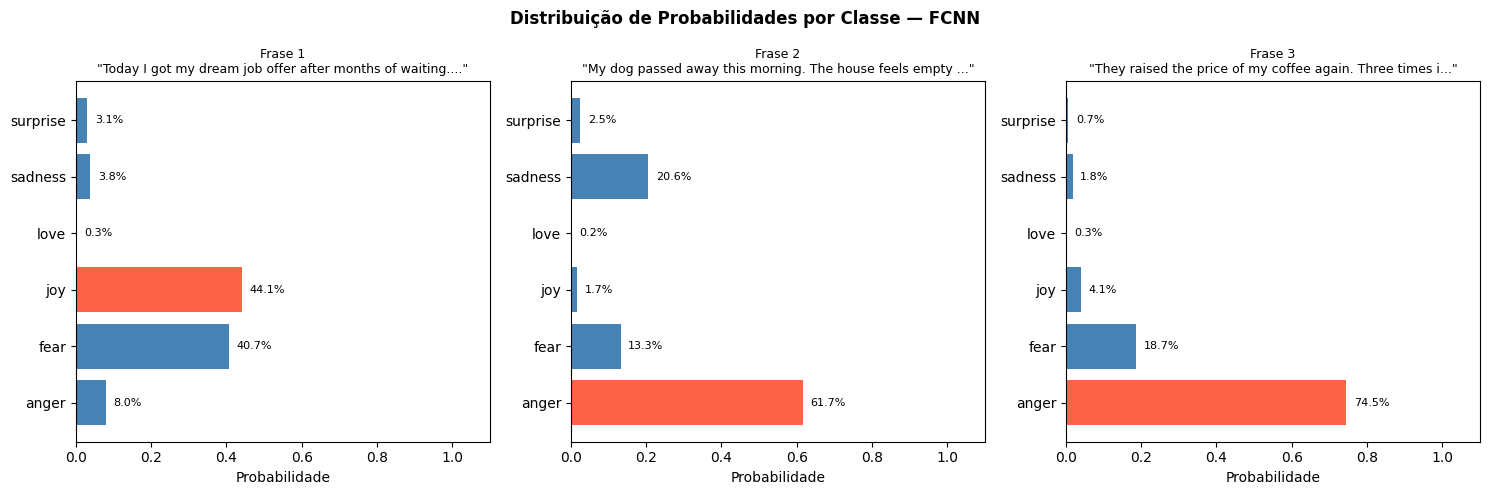

In [9]:
# frases externas — fora do escopo dos dados de treino
frases_externas = [
    "Today I got my dream job offer after months of waiting. I can barely breathe. I am ralley happy.",
    "My dog passed away this morning. The house feels empty without him.",
    "They raised the price of my coffee again. Three times in one year!",
]

# pré-processamento com spaCy (mesmo pipeline usado no treino)
frases_processadas = [spacy_preprocess_text(f) for f in frases_externas]

# vetorização com o TF-IDF ajustado no treino (apenas transform, nunca fit_transform)
X_ext = tfidf_fcnn.transform(frases_processadas).astype(np.float32).toarray()

# predição: probabilidades por classe
probs_ext = model_fcnn.predict(X_ext, verbose=0)
preds_ext = probs_ext.argmax(axis=-1)
labels_ext = le_global.inverse_transform(preds_ext)

# resultados textuais
print('=== Predições: FCNN ===\n')
for i, (frase, label, prob) in enumerate(zip(frases_externas, labels_ext, probs_ext)):
    print(f'Frase {i + 1}: "{frase}"')
    print(f'  → Classe predita : {label.upper()}  (confiança: {prob.max():.1%})')
    print(f'  → Texto processado: "{frases_processadas[i]}"\n')

# visualização: distribuição de probabilidades por classe
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (frase, prob, pred) in enumerate(zip(frases_externas, probs_ext, labels_ext)):
    cores = ['tomato' if c == pred else 'steelblue' for c in class_names]
    bars  = axes[i].barh(class_names, prob, color=cores)
    titulo = f'Frase {i + 1}\n"{frase[:55]}..."' if len(frase) > 55 else f'Frase {i + 1}\n"{frase}"'
    axes[i].set_title(titulo, fontsize=9)
    axes[i].set_xlim(0, 1.1)
    axes[i].set_xlabel('Probabilidade')
    for bar, p in zip(bars, prob):
        axes[i].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                     f'{p:.1%}', va='center', fontsize=8)

plt.suptitle('Distribuição de Probabilidades por Classe — FCNN', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">Salvamento do Modelo</span>

</div>

Para reutilizar o modelo em produção ou em notebooks futuros, é necessário salvar **todos os artefatos do pipeline de inferência** — não apenas os pesos da rede. Para a FCNN, três arquivos são necessários:

| Arquivo | Conteúdo | Usado para |
|---------|----------|------------|
| `fcnn_sentiment.keras` | Pesos e arquitetura do modelo | Predição |
| `fcnn_tfidf.pkl` | Vocabulário e pesos IDF do `TfidfVectorizer` | Converter texto → vetor TF-IDF |
| `fcnn_label_encoder.pkl` | Mapeamento id ↔ rótulo | Converter id numérico → nome da classe |

Para recarregar e usar o modelo:

```python
import pickle
from tensorflow.keras.models import load_model

model  = load_model('models/fcnn_sentiment.keras')
tfidf  = pickle.load(open('models/fcnn_tfidf.pkl', 'rb'))
le     = pickle.load(open('models/fcnn_label_encoder.pkl', 'rb'))

texto = ["I feel so happy today!"]
X     = tfidf.transform(texto).astype('float32').toarray()
pred  = le.inverse_transform(model.predict(X).argmax(axis=-1))
print(pred)
```

In [10]:
import pickle
import os

os.makedirs('models', exist_ok=True)

# salva os pesos e a arquitetura do modelo FCNN no formato nativo do Keras
model_fcnn.save('models/fcnn_sentiment.keras')

# salva o TfidfVectorizer (vocabulário e pesos IDF) necessário para vetorizar novos textos
with open('models/fcnn_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf_fcnn, f)

# salva o LabelEncoder (mapeamento id ↔ rótulo) necessário para interpretar as predições
with open('models/fcnn_label_encoder.pkl', 'wb') as f:
    pickle.dump(le_global, f)

print('Artefatos salvos em models/:')
for fname in ['fcnn_sentiment.keras', 'fcnn_tfidf.pkl', 'fcnn_label_encoder.pkl']:
    path = f'models/{fname}'
    size = os.path.getsize(path) / 1024
    print(f'  {fname:32s}  {size:7.1f} KB')

Artefatos salvos em models/:
  fcnn_sentiment.keras              35035.7 KB
  fcnn_tfidf.pkl                      440.7 KB
  fcnn_label_encoder.pkl                0.3 KB
